In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [2]:
df = pd.read_parquet(r'C:\Users\rashid\Desktop\funnel_analysis\data\processed\cleaned_data.parquet')
print(df.shape)
df.head()

(7956044, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00+00:00,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09+00:00,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19+00:00,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24+00:00,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25+00:00,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7956044 entries, 0 to 7956043
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 899.2 MB


In [ ]:
#event type distribution
print("--- HADİSƏ NÖVLƏRİNİN PAYLANMASI (EVENT TYPE DISTRIBUTION) ---")
event_counts = df['event_type'].value_counts()
event_percents = df['event_type'].value_counts(normalize=True) * 100

event_dist = pd.DataFrame({'Say': event_counts, 'Faiz (%)': event_percents.round(2)})
print(event_dist)
print("\n" + "="*50 + "\n")

#funnel mərhələləri üzrə unikal istifadəçi sayı
view_users = set(df[df['event_type'] == 'view']['user_id'].unique())
cart_users = set(df[df['event_type'] == 'cart']['user_id'].unique())
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'].unique())

stage1 = len(view_users)
stage2 = len(cart_users)
stage3 = len(purchase_users)

# Konversiya dərəcələri (Conversion Rates)
cr_view_to_cart = (stage2 / stage1) * 100 if stage1 > 0 else 0
cr_cart_to_purchase = (stage3 / stage2) * 100 if stage2 > 0 else 0
cr_overall = (stage3 / stage1) * 100 if stage1 > 0 else 0

print("--- ƏSAS FUNNEL MƏRHƏLƏLƏRİ VƏ KONVERSİYA ---")
print(f"Stage 1 (Viewed)   : {stage1:,} unikal istifadəçi")
print(f"Stage 2 (Cart)     : {stage2:,} unikal istifadəçi")
print(f"Stage 3 (Purchase) : {stage3:,} unikal istifadəçi")
print("-" * 35)
print(f"CR: View -> Cart     : %{cr_view_to_cart:.2f}")
print(f"CR: Cart -> Purchase : %{cr_cart_to_purchase:.2f}")
print(f"CR: View -> Purchase : %{cr_overall:.2f} (Ümumi Konversiya)")
print("\n" + "="*50 + "\n")

#top 8 kateqoriyaları tapırıq
top_8_categories = (
    df[df['event_type'] == 'view']['category_code']
    .dropna()
    .value_counts()
    .head(8)
    .index
    .tolist()
)

# Yalnız bu top 8 kateqoriyaya aid datanı süzürük
df_top8 = df[df['category_code'].isin(top_8_categories)]

# Kateqoriyalar üzrə unikal istifadəçiləri hesablamaq üçün funksiya
cat_funnel = df_top8.groupby('category_code').agg(
    view_users=('user_id', lambda x: x[df_top8.loc[x.index, 'event_type'] == 'view'].nunique()),
    cart_users=('user_id', lambda x: x[df_top8.loc[x.index, 'event_type'] == 'cart'].nunique()),
    purchase_users=('user_id', lambda x: x[df_top8.loc[x.index, 'event_type'] == 'purchase'].nunique())
).reset_index()

# Konversiyaların hesablanması
cat_funnel['View -> Cart (%)'] = (cat_funnel['cart_users'] / cat_funnel['view_users'] * 100).round(2)
cat_funnel['Cart -> Purchase (%)'] = (cat_funnel['purchase_users'] / cat_funnel['cart_users'] * 100).round(2)
cat_funnel['Overall CR (%)'] = (cat_funnel['purchase_users'] / cat_funnel['view_users'] * 100).round(2)

cat_funnel = cat_funnel.sort_values(by='view_users', ascending=False).reset_index(drop=True)

print("--- TOP 8 KATEQORİYA ÜZRƏ FUNNEL METRİKALARI ---")
print(cat_funnel.to_string(index=False))
"""
View→Cart 22.60%, amma Cart→Purchase cəmi 30.53%. Yəni səbətə əlavə edən 162K istifadəçidən yalnız
49K alış edir — qalan 70% ya tərk edir, ya da remove_from_cart edir (87,245 unikal user, bütün eventlərin 15.24%-i).

Solution olaraq:
art-da qalan məhsullara görə retargeting email/push (24-48 saat pəncərəsi) qurmaq olar və yaxud da 
checkout addımlarını sadələşdirmək lazımdır. Checkout addımlarını sadələşdirmək üçün isə, məsələn, guest checkout, autofill, payment method optimization və s. kimi addımlar atmaq olar.
"""
"""
apparel.glove (38.91%) və stationery.cartrige (23.77%) çox yüksək CR göstərir, amma accessories.bag (1.43%) və
furniture.living_room.cabinet (2.21%) demək olar ki, işləmir — baxmayaraq ki, bag kateqoriyasına 3,147 view gəlib.

Solution olaraq:
- accessories.bag üçün məhsul səhifəsini optimizasiya etmək olar (məsələn, daha yaxşı şəkillər, məhsul təsviri, reviews və s.)
- furniture.living_room.cabinet üçün isə, ya məhsul səhifəsini optimizasiya etmək, ya da bu məhsullar üçün retargeting kampaniyaları qurmaq olar.
- ve əsas olaraq da yüksək-CR kateqoriyaları (glove, stationery) homepage/promo bannerlərdə daha çox önə çıxarmaq lazımdır.

"""

--- HADİSƏ NÖVLƏRİNİN PAYLANMASI (EVENT TYPE DISTRIBUTION) ---
                      Say  Faiz (%)
event_type                         
view              3990526     50.16
cart              2247500     28.25
remove_from_cart  1212532     15.24
purchase           505486      6.35


--- ƏSAS FUNNEL MƏRHƏLƏLƏRİ VƏ KONVERSİYA ---
Stage 1 (Viewed)   : 716,987 unikal istifadəçi
Stage 2 (Cart)     : 162,035 unikal istifadəçi
Stage 3 (Purchase) : 49,473 unikal istifadəçi
-----------------------------------
CR: View -> Cart     : %22.60
CR: Cart -> Purchase : %30.53
CR: View -> Purchase : %6.90 (Ümumi Konversiya)


--- TOP 8 KATEQORİYA ÜZRƏ FUNNEL METRİKALARI ---
                  category_code  view_users  cart_users  purchase_users  View -> Cart (%)  Cart -> Purchase (%)  Overall CR (%)
  appliances.environment.vacuum       15431        3883            1366             25.16                 35.18            8.85
  furniture.living_room.cabinet        5377         760             119           

------------

In [7]:
df['month'] = df['event_time'].dt.month_name()

In [ ]:
monthly_funnel = df.groupby(['month', 'event_type'])['user_id'].nunique().unstack(fill_value=0)

monthly_funnel['Overall_CR (%)'] = (monthly_funnel['purchase'] / monthly_funnel['view'] * 100).round(2)
monthly_funnel['View_to_Cart (%)'] = (monthly_funnel['cart'] / monthly_funnel['view'] * 100).round(2)
monthly_funnel['Cart_to_Purchase (%)'] = (monthly_funnel['purchase'] / monthly_funnel['cart'] * 100).round(2)
monthly_funnel.reset_index()
"""
Yanvar CR 7.09%, Fevral CR 6.79%. Kiçik görünsə də, mütləq ədədlərdə həm view, həm cart, həm purchase sayları da azalıb 
(məs. purchase 28,220 → 25,759) — sadəcə mövsümi trend deyil, ümumi fəallıqda azalma var.

Solutin olaraq:
- Yanvar və Fevral ayları üçün, həm view, həm cart, həm purchase saylarını artırmaq üçün, məsələn, mövsümi kampaniyalar, endirimlər və s. kimi tədbirlər görülə bilər.
- Sezon sonu xususi endirim kampaniyaları, loyalty proqramları və s. kimi tədbirlər də ROI baxımından faydalı ola bilər.
- Yanvar ayı üçün əslində bu fərq normaldı çünkü yanvar ayı bayram sonrası dövr olduğu üçün, Fevral ayına nisbətən daha çox alış-veriş olur. 
Amma Fevral ayında da bu azalma davam edirsə, bu, istifadəçi davranışında dəyişiklik olduğunu göstərə bilər.

"""

event_type,month,cart,purchase,remove_from_cart,view,Overall_CR (%),View_to_Cart (%),Cart_to_Purchase (%)
0,February,89269,25759,49053,379246,6.79,23.54,28.86
1,January,92653,28220,51107,397775,7.09,23.29,30.46


In [16]:
jan_cr = monthly_funnel.loc['January', 'Overall_CR (%)']
feb_cr = monthly_funnel.loc['February', 'Overall_CR (%)']
diff = feb_cr - jan_cr
print("\n" + "="*50)
if diff > 0:
    print(f"FAYDA / YAXŞILAŞMA: Ümumi konversiya dərəcəsi Yanvardan (%{jan_cr}) Fevrala (%{feb_cr}) +{diff:.2f}% ARTIB!")
elif diff < 0:
    print(f"ENİŞ: Ümumi konversiya dərəcəsi Yanvardan (%{jan_cr}) Fevrala (%{feb_cr}) {diff:.2f}% DÜŞÜB!")
else:
    print(f"DƏYİŞMƏYİB: Hər iki ayda konversiya dərəcəsi eynidir (%{jan_cr}).")


ENİŞ: Ümumi konversiya dərəcəsi Yanvardan (%7.09) Fevrala (%6.79) -0.30% DÜŞÜB!


----------

In [ ]:
brand_purchases = df[df['event_type'] == 'purchase']['brand'].value_counts()
top_10_brands = brand_purchases.head(10).index.tolist()

df_top_brands = df[df['brand'].isin(top_10_brands)]

brand_metrics = df_top_brands.groupby('brand').agg(
    total_views=('event_type', lambda x: (x == 'view').sum()),
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),
    unique_viewers=('user_id', lambda x: x[df_top_brands.loc[x.index, 'event_type'] == 'view'].nunique()),
    unique_buyers=('user_id', lambda x: x[df_top_brands.loc[x.index, 'event_type'] == 'purchase'].nunique())
).reset_index()


brand_metrics['View_to_Purchase_Rate (%)'] = (brand_metrics['total_purchases'] / brand_metrics['total_views'] * 100).round(2)
brand_metrics['User_View_to_Purchase_Rate (%)'] = (brand_metrics['unique_buyers'] / brand_metrics['unique_viewers'] * 100).round(2)

brand_metrics = brand_metrics.sort_values(by='total_purchases', ascending=False).reset_index(drop=True)

print("--- TOP 10 BREND VƏ KONVERSİYA DƏRƏCƏSİ ---")
print(brand_metrics[['brand', 'total_purchases', 'total_views', 'View_to_Purchase_Rate (%)']])
print("\n" + "="*60 + "\n")
"""
estel brendi 40,234 unikal viewer alır, amma yalnız 9.93% konversiya edir — bu top-10 brendlər arasında ən aşağısıdır.
Əksinə, bpw.style az trafiklə (13,376 viewer) 22.95% CR göstərir — ən yüksək göstəricidir.
-
bpw.style kimi yüksək-konversiyalı, aşağı-görünürlüklü brendlərə əlavə 
trafik/promo büdcəsi yönləndirmək — ROI baxımından daha səmərəli ola bilər.
estel brendi üçün isə, məhsul səhifəsini optimizasiya etmək (məsələn, daha yaxşı şəkillər, məhsul təsviri, reviews və s.) və retargeting kampaniyaları qurmaq olar.
"""

--- TOP 10 BREND VƏ KONVERSİYA DƏRƏCƏSİ ---
       brand  total_purchases  total_views  View_to_Purchase_Rate (%)
0     runail            45235       256966                      17.60
1      irisk            31181       179821                      17.34
2    grattol            21320       178941                      11.91
3     masura            19862       143082                      13.88
4   ingarden            10273        71509                      14.37
5      estel             8615        90037                       9.57
6  bpw.style             8436        43528                      19.38
7        uno             6871        50037                      13.73
8    italwax             6719        46168                      14.55
9     kapous             6368        86507                       7.36




----------

In [ ]:
purchases_df = df[df['event_type'] == 'purchase']

Q1 = purchases_df['price'].quantile(0.25)
Q3 = purchases_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier-lərin süzülməsi
outliers = purchases_df[(purchases_df['price'] < lower_bound) | (purchases_df['price'] > upper_bound)]
normal_purchases = purchases_df[(purchases_df['price'] >= lower_bound) & (purchases_df['price'] <= upper_bound)]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Ümumi Alış Sayı: {len(purchases_df):,}")
print(f"Outlier Alış Sayı: {len(outliers):,} (%{(len(outliers)/len(purchases_df)*100):.2f})")
"""
View mərhələsində orta qiymət $12.44, purchase mərhələsində isə cəmi $5.00 — istifadəçilər baha məhsullara baxır, amma ucuz olanları alır. Həm də purchase-larda 
34,919 outlier (bütün alışların ~6.9%-i) IQR sərhədlərindən kənarda idi.
"""


Q1: 1.59, Q3: 5.56, IQR: 3.97
Lower Bound: -4.37, Upper Bound: 11.52
Ümumi Alış Sayı: 505,486
Outlier Alış Sayı: 34,919 (%6.91)


--------------

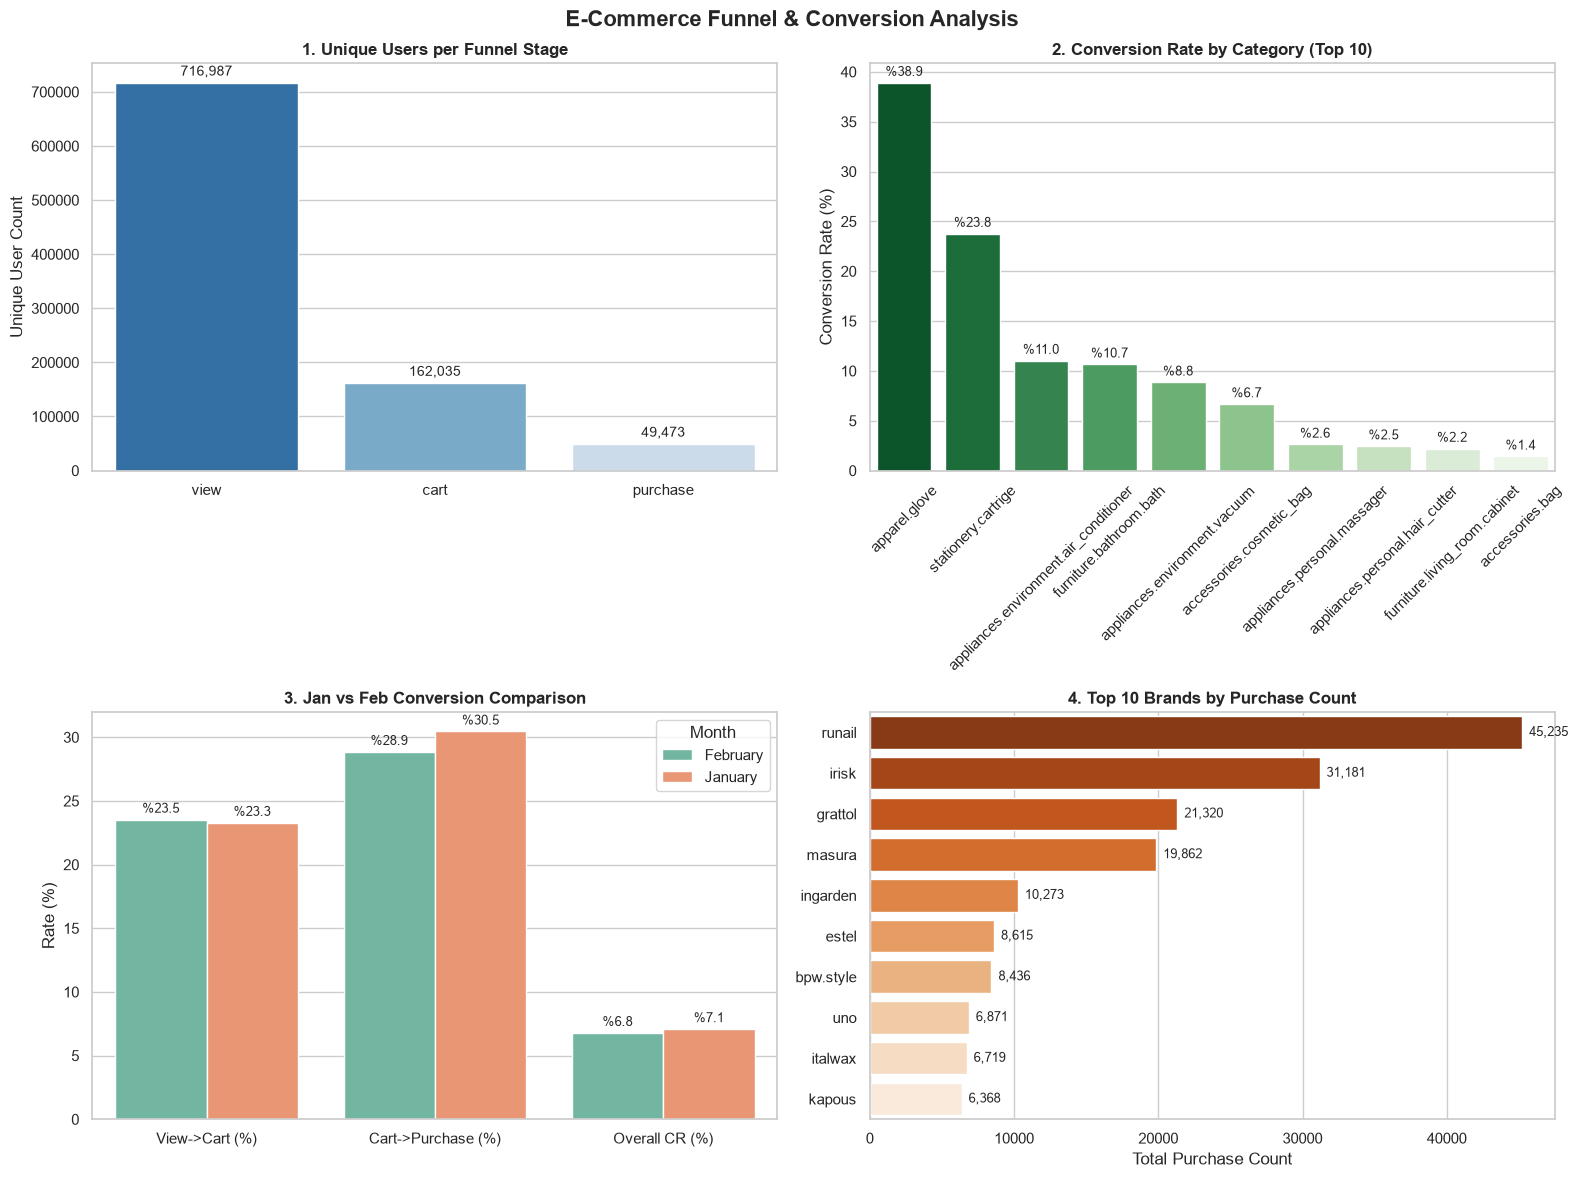

In [23]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Funnel & Conversion Analysis', fontsize=16, fontweight='bold', y=0.98)

#Funnel bar chart
funnel_df = df.groupby('event_type')['user_id'].nunique().reset_index()
funnel_df.columns = ['Stage', 'Users']

# Stage sırasını düzgün tənzimləyirik
stage_order = ['view', 'cart', 'purchase']
funnel_df['Stage'] = pd.Categorical(funnel_df['Stage'], categories=stage_order, ordered=True)
funnel_df = funnel_df.sort_values('Stage')

ax1 = axes[0, 0]
sns.barplot(data=funnel_df, x='Stage', y='Users', palette='Blues_r', ax=ax1)
ax1.set_title('1. Unique Users per Funnel Stage', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Unique User Count')

for p in ax1.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax1.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                     textcoords='offset points')

#Conversion Rate by Category (Top 10 Categories)
top_10_cats = df[df['event_type'] == 'view']['category_code'].dropna().value_counts().head(10).index
df_top_cat = df[df['category_code'].isin(top_10_cats)]

cat_funnel = df_top_cat.groupby('category_code').agg(
    views=('user_id', lambda x: x[df_top_cat.loc[x.index, 'event_type'] == 'view'].nunique()),
    purchases=('user_id', lambda x: x[df_top_cat.loc[x.index, 'event_type'] == 'purchase'].nunique())
).reset_index()

cat_funnel['CR (%)'] = (cat_funnel['purchases'] / cat_funnel['views'] * 100).round(2)
cat_funnel = cat_funnel.sort_values('CR (%)', ascending=False)

ax2 = axes[0, 1]
sns.barplot(data=cat_funnel, x='category_code', y='CR (%)', palette='Greens_r', ax=ax2)
ax2.set_title('2. Conversion Rate by Category (Top 10)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Conversion Rate (%)')
ax2.tick_params(axis='x', rotation=45)

for p in ax2.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax2.annotate(f'%{height:.1f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

#Jan vs Feb Conversion Comparison
df_jan_feb = df[df['month'].isin(['January', 'February'])]

monthly_stats = df_jan_feb.groupby(['month', 'event_type'])['user_id'].nunique().unstack(fill_value=0)
monthly_stats['Overall CR (%)'] = (monthly_stats['purchase'] / monthly_stats['view'] * 100).round(2)
monthly_stats['View->Cart (%)'] = (monthly_stats['cart'] / monthly_stats['view'] * 100).round(2)
monthly_stats['Cart->Purchase (%)'] = (monthly_stats['purchase'] / monthly_stats['cart'] * 100).round(2)

monthly_melted = monthly_stats[['View->Cart (%)', 'Cart->Purchase (%)', 'Overall CR (%)']].reset_index().melt(
    id_vars='month', var_name='Metric', value_name='Rate'
)

ax3 = axes[1, 0]
sns.barplot(data=monthly_melted, x='Metric', y='Rate', hue='month', palette='Set2', ax=ax3)
ax3.set_title('3. Jan vs Feb Conversion Comparison', fontsize=12, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Rate (%)')
ax3.legend(title='Month')

for p in ax3.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax3.annotate(f'%{height:.1f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

#Top 10 Brands by Purchase Count
top_brands = (
    df[df['event_type'] == 'purchase']['brand']
    .dropna()
    .value_counts()
    .head(10)
    .reset_index()
)
top_brands.columns = ['brand', 'purchases']

ax4 = axes[1, 1]
sns.barplot(data=top_brands, y='brand', x='purchases', palette='Oranges_r', ax=ax4)
ax4.set_title('4. Top 10 Brands by Purchase Count', fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Purchase Count')
ax4.set_ylabel('')

for p in ax4.patches:
    width = p.get_width()
    if not pd.isna(width) and width > 0:
        ax4.annotate(f'{int(width):,}',
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=9, xytext=(5, 0),
                     textcoords='offset points')

plt.tight_layout()

---------------------

In [ ]:
#Convert olmuş istifadəçilər üçün view→purchase arası ortalama vaxt
vp = df[df['event_type'].isin(['view', 'purchase'])].copy()

first_times = (
    vp.groupby(['user_id', 'product_id', 'event_type'])['event_time']
    .min()
    .unstack('event_type')
    .dropna(subset=['view', 'purchase'])  
)

first_times = first_times[first_times['purchase'] >= first_times['view']]
first_times['time_to_purchase'] = first_times['purchase'] - first_times['view']

avg_ttp = first_times['time_to_purchase'].mean()
median_ttp = first_times['time_to_purchase'].median()

print(f"Ortalama view->purchase vaxtı: {avg_ttp}")
print(f"Median view->purchase vaxtı: {median_ttp}")


first_times['hours_to_purchase'] = first_times['time_to_purchase'].dt.total_seconds() / 3600
print(first_times['hours_to_purchase'].describe())

Ortalama view->purchase vaxtı: 2 days 06:04:19.439982
Median view->purchase vaxtı: 0 days 01:07:43
count   174082.00
mean        54.07
std        140.31
min          0.00
25%          0.26
50%          1.13
75%         27.40
max       1415.58
Name: hours_to_purchase, dtype: float64


------------------------------

In [ ]:
#Cox axtarilan ancaq nadiren alinan məhsulların tapılması üçün
product_stats = df.groupby('product_id').agg(
    views=('event_type', lambda x: (x == 'view').sum()),
    purchases=('event_type', lambda x: (x == 'purchase').sum()),
    brand=('brand', 'first'),
    category_code=('category_code', 'first')
).reset_index()

product_stats['conversion_rate'] = (
    product_stats['purchases'] / product_stats['views'] * 100
).round(2)
min_views = 100
candidates = product_stats[product_stats['views'] >= min_views]

underperformers = candidates.sort_values(
    by=['views', 'conversion_rate'],
    ascending=[False, True]
)
global_cr = product_stats['purchases'].sum() / product_stats['views'].sum() * 100
candidates['cr_gap'] = global_cr - candidates['conversion_rate']

top_underperformers = candidates.sort_values(
    by='cr_gap', ascending=False
).head(20)

print(f"Qlobal ortalama CR: {global_cr:.2f}%")
print(top_underperformers[['product_id', 'brand', 'category_code', 'views', 'purchases', 'conversion_rate']])

Qlobal ortalama CR: 12.67%
       product_id     brand                 category_code  views  purchases  \
28           3945       cnd                           NaN    100          0   
69           4200       cnd                           NaN    265          0   
49095     5926218  gezatone  appliances.personal.massager    128          0   
34896     5865795       NaN                           NaN    130          0   
3182      5584538       NaN           stationery.cartrige    375          0   
8689      5706830       NaN                           NaN    476          0   
48977     5925383  gezatone                           NaN    166          0   
264          4934       NaN               accessories.bag    335          0   
3459      5597372       cnd                           NaN    104          0   
177          4665       cnd                           NaN    156          0   
36966     5875271       NaN                           NaN    193          0   
33894     5862721     keu